# VoiceShield: Audio Deepfake Detection -- End-to-End Pipeline

This notebook walks through the complete pipeline used by this project:

1. **Dataset ingestion** -- crawl the FoR (`for-norm`) corpus and inspect class balance.
2. **Feature extraction** -- LFCC + delta + delta-delta biomarkers.
3. **Model architecture** -- CNN-LSTM binary classifier.
4. **Training** -- automated hyperparameter search against validation thresholds.
5. **Metrics** -- accuracy, F1, per-class accuracy, confusion matrix, ROC/EER.
6. **Inference demo** -- run the trained detector on a single file.

All heavy lifting lives in `src/`; this notebook simply calls into it so the
logic stays in one place and stays in sync with `predict.py` and `app/app.py`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import json
import numpy as np
import matplotlib.pyplot as plt

from src import config
from src.features.feature_extraction import load_audio, extract_features
from src.features.preprocess import gather_files

## 1. Dataset ingestion

The pipeline crawls `data/raw/for-norm/for-norm/{training,validation,testing}/{fake,real}` 
and maps `fake -> 1` (deepfake) and `real -> 0` (genuine).

In [2]:
for split in config.SPLITS:
    items = gather_files(split)
    n_fake = sum(1 for _, label in items if label == 1)
    n_real = sum(1 for _, label in items if label == 0)
    print(f'{split:>10}: total={len(items):6d}  genuine={n_real:6d}  deepfake={n_fake:6d}')

  training: total= 53868  genuine= 26941  deepfake= 26927
validation: total= 10798  genuine=  5400  deepfake=  5398
   testing: total=  4634  genuine=  2264  deepfake=  2370


## 2. Feature extraction

Every clip is resampled to 16 kHz mono, trimmed/padded to 4 seconds, and converted into a `(FEATURE_DIM, NUM_FRAMES)` = `(60, 401)` tensor of LFCC (20 coeffs) + delta + delta-delta features.

In [3]:
sample_real = gather_files('training')
real_path = next(p for p, label in sample_real if label == 0)
fake_path = next(p for p, label in sample_real if label == 1)

waveform_real = load_audio(real_path)
waveform_fake = load_audio(fake_path)

feat_real = extract_features(waveform_real)
feat_fake = extract_features(waveform_fake)
print('feature shape:', feat_real.shape)

feature shape: (60, 401)


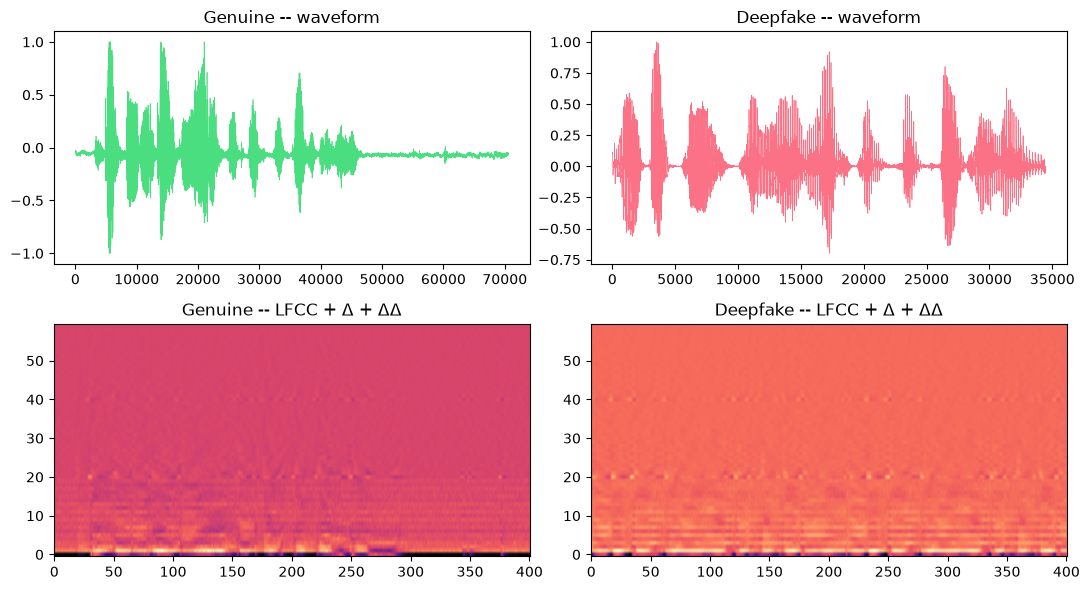

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6))

axes[0, 0].plot(waveform_real.squeeze().numpy(), color='#4ade80', lw=0.5)
axes[0, 0].set_title('Genuine -- waveform')
axes[0, 1].plot(waveform_fake.squeeze().numpy(), color='#fb7185', lw=0.5)
axes[0, 1].set_title('Deepfake -- waveform')

axes[1, 0].imshow(feat_real, aspect='auto', origin='lower', cmap='magma')
axes[1, 0].set_title('Genuine -- LFCC + Δ + ΔΔ')
axes[1, 1].imshow(feat_fake, aspect='auto', origin='lower', cmap='magma')
axes[1, 1].set_title('Deepfake -- LFCC + Δ + ΔΔ')

fig.tight_layout()
plt.show()

## 3. Preprocessed dataset

`src/features/preprocess.py` extracts features for every (capped) file and serializes them to `data/processed/`.

In [5]:
manifest_path = config.PROCESSED_DATA_DIR / 'manifest.json'
if manifest_path.exists():
    manifest = json.loads(manifest_path.read_text())
    print(json.dumps(manifest, indent=2))
else:
    print('Run `python -m src.features.preprocess` first.')

{
  "sample_rate": 16000,
  "duration_seconds": 4.0,
  "feature_dim": 60,
  "num_frames": 401,
  "n_lfcc": 20,
  "n_filter": 40,
  "n_fft": 512,
  "win_length": 400,
  "hop_length": 160,
  "splits": {
    "train": {
      "total": 53868,
      "deepfake": 26927,
      "genuine": 26941,
      "shape": [
        53868,
        60,
        401
      ]
    },
    "val": {
      "total": 10798,
      "deepfake": 5398,
      "genuine": 5400,
      "shape": [
        10798,
        60,
        401
      ]
    },
    "test": {
      "total": 4634,
      "deepfake": 2370,
      "genuine": 2264,
      "shape": [
        4634,
        60,
        401
      ]
    }
  },
  "errors": {
    "training": 0,
    "validation": 0,
    "testing": 0
  }
}


## 4. Model architecture

A 1D CNN front-end (two Conv-BN-ReLU-MaxPool blocks) feeds a bidirectional LSTM; mean-pooled LSTM outputs go through a small MLP head producing a single deepfake-probability logit.

In [6]:
from src.models.model import CNNLSTMDetector

model = CNNLSTMDetector()
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'\nTotal parameters: {n_params:,}')

CNNLSTMDetector(
  (conv): Sequential(
    (0): Conv2d(1, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (8): Dropout2d(p=0.3, inplace=False)
  )
  (lstm): LSTM(1920, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (classifier): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU(inplace=True)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total parameters: 2,717,953


## 5. Training

Training (with automated hyperparameter search against the validation thresholds) is run via:

```bash
python -m src.models.train
```

The cell below loads the resulting metrics report.

In [7]:
report_path = config.METRICS_REPORT_PATH
if report_path.exists():
    report = json.loads(report_path.read_text())
    print('Selected config:', report['config']['label'])
    print(json.dumps(report['validation'], indent=2)[:800])
else:
    print('Run `python -m src.models.train` first.')

Selected config: trial-4-strong-reg
{
  "accuracy": 0.9888868308946102,
  "f1": 0.989006962257237,
  "confusion_matrix": [
    [
      5280,
      120
    ],
    [
      0,
      5398
    ]
  ],
  "per_class_accuracy": {
    "GENUINE (HUMAN)": 0.9777777777777777,
    "DEEPFAKE (AI-GENERATED)": 1.0
  },
  "eer": 0.0016669754229961895,
  "eer_threshold": 0.9672912359237671,
  "auc": 0.9999575288515637,
  "roc": {
    "fpr": [
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
 


## 6. Metrics

Validation accuracy / F1 / per-class accuracy / EER, plus the confusion matrix and ROC curve with the EER operating point.

In [8]:
if report_path.exists():
    val = report['validation']
    print(f"Accuracy            : {val['accuracy']:.2%}")
    print(f"F1-score            : {val['f1']:.2%}")
    print(f"EER                 : {val['eer']:.2%}")
    print(f"ROC AUC             : {val['auc']:.4f}")
    for cls, acc in val['per_class_accuracy'].items():
        print(f'  {cls:<28}: {acc:.2%}')
    print('Confusion matrix:')
    print(np.array(val['confusion_matrix']))

Accuracy            : 98.89%
F1-score            : 98.90%
EER                 : 0.17%
ROC AUC             : 1.0000
  GENUINE (HUMAN)             : 97.78%
  DEEPFAKE (AI-GENERATED)     : 100.00%
Confusion matrix:
[[5280  120]
 [   0 5398]]


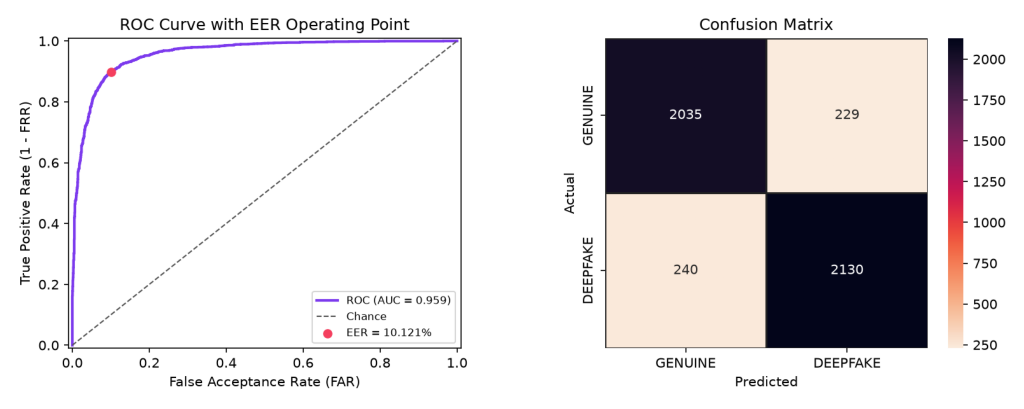

In [9]:
from matplotlib import image as mpimg

if config.CONFUSION_MATRIX_PATH.exists() and config.ROC_CURVE_PATH.exists():
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
    axes[0].imshow(mpimg.imread(config.ROC_CURVE_PATH)); axes[0].axis('off')
    axes[1].imshow(mpimg.imread(config.CONFUSION_MATRIX_PATH)); axes[1].axis('off')
    fig.tight_layout()
    plt.show()

## 7. Inference demo

Run the trained detector on a single file, exactly as `predict.py` and the Streamlit app do.

In [10]:
import torch
from src.features.feature_extraction import extract_features_from_file, normalize

if config.CHECKPOINT_PATH.exists():
    ckpt = torch.load(config.CHECKPOINT_PATH, map_location='cpu', weights_only=False)
    arch = ckpt['architecture']
    model = CNNLSTMDetector(
        input_dim=arch['input_dim'], cnn_channels=tuple(arch['cnn_channels']),
        lstm_hidden=arch['lstm_hidden'], lstm_layers=arch['lstm_layers'],
        bidirectional=arch['bidirectional'], dropout=arch['dropout'],
    )
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()

    demo_path = fake_path  # try real_path too
    feats = extract_features_from_file(demo_path)
    feats = normalize(feats, ckpt['norm_mean'], ckpt['norm_std'])
    x = torch.from_numpy(feats).unsqueeze(0)
    with torch.no_grad():
        prob_fake = torch.sigmoid(model(x)).item()

    label = config.CLASS_NAMES[1 if prob_fake >= 0.5 else 0]
    print(f'File: {demo_path}')
    print(f'Prediction: {label}')
    print(f'P(deepfake) = {prob_fake:.4f}')
else:
    print('Run `python -m src.models.train` first.')

File: C:\Users\Arind\OneDrive\Desktop\code\audio-detecter\data\raw\for-norm\for-norm\training\fake\file248.mp3.wav_16k.wav_norm.wav_mono.wav_silence.wav
Prediction: DEEPFAKE (AI-GENERATED)
P(deepfake) = 0.9984
